In [7]:
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, auc, precision_recall_curve, 
                             roc_auc_score, roc_curve)
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import MultiLabelBinarizer

from utils import fit_and_eval_cls, to_long_with_offsets, build_day_level_df

In [8]:
df = pd.read_csv("../data/patient_features_with_encounter_cluster.csv")

df['encounter_start_dt'] = pd.to_datetime(df['encounter_start_dt'], errors='coerce')
df['encounter_end_dt']   = pd.to_datetime(df['encounter_end_dt'],   errors='coerce')

df.proc_descs_seq_str

base_features = [
    'age', 'PATIENT_SEX', 'PATIENT_RACE_ETHNICITY',
    'encounter_medical_service', 'n_icd_prefix3',
    'past_num_encounters', 'past_total_procedures',
    'past_total_icd_codes', 'past_total_encounter_days'
    # DO NOT include encounter_setting
]
base_features    = [c for c in base_features if c in df.columns]

In [9]:
all_columns = ['patient_id', 'encounter_id', 'icd_prefix3_unique_str', 'n_icd_prefix3',
       'encounter_start_dt', 'encounter_end_dt', 'encounter_duration_days',
       'encounter_setting', 'encounter_medical_service',
       'adt_event_types_seq_str', 'adt_event_times_seq_str',
       'PATIENT_BIRTH_YEAR', 'PATIENT_SEX', 'PATIENT_RACE_ETHNICITY',
       'DECEASED_FLAG', 'age', 'med_order_nunique', 'proc_codes_seq_str',
       'proc_descs_seq_str', 'proc_times_seq_str', 'proc_count',
       'past_num_encounters', 'past_total_procedures', 'past_total_icd_codes',
       'past_total_encounter_days', 'encounter_cluster']

In [10]:
df.proc_times_seq_str

0        2022-11-19 00:00:00|2022-11-20 00:00:00|2022-1...
1        2022-11-10 00:00:00|2022-11-10 00:00:00|2022-1...
2                                                      NaN
3        2023-02-08 00:00:00|2023-02-09 00:00:00|2023-0...
4        2022-12-10 00:00:00|2022-12-10 00:00:00|2022-1...
                               ...                        
15111    2022-12-02 00:00:00|2022-12-02 00:00:00|2022-1...
15112    2023-02-01 00:00:00|2023-02-01 00:00:00|2023-0...
15113    2023-02-26 00:00:00|2023-02-26 00:00:00|2023-0...
15114    2023-02-12 00:00:00|2023-02-12 00:00:00|2023-0...
15115    2023-02-02 00:00:00|2023-02-02 00:00:00|2023-0...
Name: proc_times_seq_str, Length: 15116, dtype: object

In [11]:
mlb = MultiLabelBinarizer(sparse_output=True)
df["proc_descs_seq_list"] = df.proc_descs_seq_str.fillna("").apply(
    lambda x: [str(code).strip() for code in x.split("|")] if x else []
)
proc_code_mlb = mlb.fit_transform(df["proc_descs_seq_list"])

codes_df = pd.DataFrame.sparse.from_spmatrix(
    proc_code_mlb,
    columns=mlb.classes_,
    index = df.index
)
mlb_columns = [i for i in list(mlb.classes_) if i not in df.columns.to_list()]
# additional_columns = list(tfidf.get_feature_names_out()) + list(mlb.classes_)
additional_columns = list(set(mlb_columns))
all_df = pd.concat([df, codes_df[mlb_columns]], axis=1)

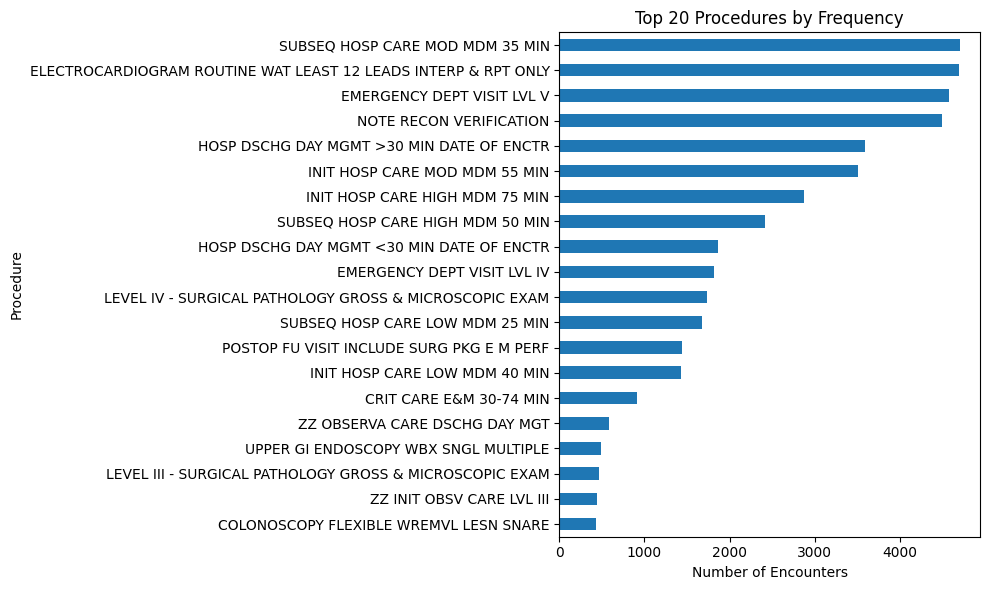

In [12]:
# series from earlier cell
procedure_counts = (df['proc_descs_seq_str'].fillna('')
      .astype(str)
      .str.split('|')
      .apply(lambda lst: {s.strip() for s in lst if s and s.strip().lower() != 'nan'})
      .explode()
      .loc[lambda x: x.ne('')]
      .value_counts())

# bar plot of the most common procedures
procedure_counts.head(20).sort_values().plot(
    kind='barh', figsize=(10,6), color='C0'
)
plt.title('Top 20 Procedures by Frequency')
plt.xlabel('Number of Encounters')
plt.ylabel('Procedure')
plt.tight_layout()
plt.show()

In [13]:
groups = all_df['patient_id'].astype(str)
gkf = GroupKFold(n_splits=5)
train_idx, test_idx = next(gkf.split(all_df, groups=groups))

df_train = all_df.iloc[train_idx].reset_index(drop=True)
df_test = all_df.iloc[test_idx].reset_index(drop=True)

In [14]:
df

,patient_id,encounter_id,icd_prefix3_unique_str,n_icd_prefix3,encounter_start_dt,encounter_end_dt,encounter_duration_days,encounter_setting,encounter_medical_service,adt_event_types_seq_str,adt_event_times_seq_str,PATIENT_BIRTH_YEAR,PATIENT_SEX,PATIENT_RACE_ETHNICITY,DECEASED_FLAG,age,med_order_nunique,proc_codes_seq_str,proc_descs_seq_str,proc_times_seq_str,proc_count,past_num_encounters,past_total_procedures,past_total_icd_codes,past_total_encounter_days,encounter_cluster,proc_descs_seq_list
0,0000fa8c4cfecf9f7e26e462a990af1ad85a1bfab7f43e...,0cf2b96aa588db64f96239a66b9d8c640489f1959aa678...,"E11,E86,F31,I50,J44,N30",6,2022-11-19 00:00:00+00:00,2022-11-21 03:15:00+00:00,2.135417,Observation,Nursing - medical / surgical,Admission|Census|Census|Discharge,2022-11-19 10:32:00+0000|2022-11-19 11:59:00+0...,1948.0,Female,"White, non-Hispanic",1.0,77.0,11.0,99220|99225|99217,ZZ INIT OBSV CARE LVL III|ZZ SUBSEQ OBSV CARE ...,2022-11-19 00:00:00|2022-11-20 00:00:00|2022-1...,3.0,0,0,0,0,0,"[ZZ INIT OBSV CARE LVL III, ZZ SUBSEQ OBSV CAR..."
1,00010b29ec5fd2ad40834318f6b429961059a614fbfece...,0d79127152552683ecf7ba4acd391eeaaa6e90cceffb39...,T18,1,2022-11-10 00:00:00+00:00,2022-11-12 02:55:00+00:00,2.121528,Observation,General surgery,Admission|Transfer Out|Transfer In|Transfer Ou...,2022-11-10 07:43:00+0000|2022-11-10 11:10:00+0...,1983.0,Male,Hispanic,0.0,42.0,12.0,99219|99285|00731|99999|43247|99226|99203|9999...,ZZ INIT OBSV CARE LVL II|EMERGENCY DEPT VISIT ...,2022-11-10 00:00:00|2022-11-10 00:00:00|2022-1...,10.0,0,0,0,0,2,"[ZZ INIT OBSV CARE LVL II, EMERGENCY DEPT VISI..."
2,00069f08d03e7656de01529806a59e6f7802f7d2380b3b...,fa7ef0231ccd39aa1abedf74c1d4f4bf94fc6c01bcf421...,"E03,E66,I11,I48,I50,N30,N39,R77,R79,Z66,Z79,Z8...",13,2023-02-07 00:00:00+00:00,2023-02-07 06:24:00+00:00,0.266667,Outpatient,Emergency medicine,Admission|Discharge,2023-02-07 04:02:00+0000|2023-02-07 06:24:00+0000,1934.0,Female,"White, non-Hispanic",0.0,91.0,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,[]
3,00069f08d03e7656de01529806a59e6f7802f7d2380b3b...,dda0597e60a45d5ebc3e4e28db5df7bf3a55fd354823dd...,"B96,D69,E03,E78,E87,G70,I10,I11,I25,I27,I48,I5...",21,2023-02-07 00:00:00+00:00,2023-02-11 12:55:00+00:00,4.538194,Inpatient,Nursing - medical / surgical,Admission|Census|Census|Census|Census|Discharge,2023-02-07 06:25:00+0000|2023-02-07 11:59:00+0...,1934.0,Female,"White, non-Hispanic",0.0,91.0,13.0,99222|99232|99231|99239,INIT HOSP CARE MOD MDM 55 MIN|SUBSEQ HOSP CARE...,2023-02-08 00:00:00|2023-02-09 00:00:00|2023-0...,4.0,1,0,0,0,0,"[INIT HOSP CARE MOD MDM 55 MIN, SUBSEQ HOSP CA..."
4,0011226504d8e566cd00f2fd24dab680409b58aa39fa9b...,ebbbc7628d72c5f7d0f725857c408cd8c169736e581c92...,"I10,J10,J40,M15,R05,R06,R50,R79,Z78",9,2022-12-10 00:00:00+00:00,2022-12-15 12:49:00+00:00,5.534028,Inpatient,Nursing - medical / surgical,Admission|Transfer Out|Transfer In|Transfer Ou...,2022-12-10 03:31:00+0000|2022-12-10 06:02:00+0...,1936.0,Female,"White, non-Hispanic",1.0,89.0,24.0,99284|99223|93010|99232|99232|99232|99232|99238,EMERGENCY DEPT VISIT LVL IV|INIT HOSP CARE HIG...,2022-12-10 00:00:00|2022-12-10 00:00:00|2022-1...,8.0,0,0,0,0,0,"[EMERGENCY DEPT VISIT LVL IV, INIT HOSP CARE H..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15111,fff5c9326eba560729d167c37d88aa2e8984b408a9f198...,98409f0fc91c10e56d35df142ccdba3edd4db907c19942...,T17,1,2022-12-02 00:00:00+00:00,2022-12-03 12:15:00+00:00,1.510417,Outpatient,Emergency medicine,Admission|Transfer Out|Transfer In|Transfer In...,2022-12-02 08:47:00+0000|2022-12-02 11:01:00+0...,2006.0,Male,"White, non-Hispanic",0.0,19.0,2.0,99285|42809|99282,EMERGENCY DEPT VISIT LVL V|REMVL FB PHARYNX|EM...,2022-12-02 00:00:00|2022-12-02 00:00:00|2022-1...,3.0,0,0,0,0,2,"[EMERGENCY DEPT VISIT LVL V, REMVL FB PHARYNX,..."
15112,fff72a19bd14944c323bc685ac4bdddc031ab04a49f6c6...,f7dbf35347516e8d88f332e979fcc027075f0a958de2fb...,"M24,M62,M79,Z98",4,2023-01-25 00:00:00+00:00,2023-02

In [15]:
results = []
results_df = pd.DataFrame()

top10_procedures = (df['proc_descs_seq_str'].fillna('').astype(str)
      .str.split('|')
     .apply(lambda lst: {s.strip() for s in lst if s and s.strip().lower() != 'nan'})
      .explode()
      .loc[lambda x: x.ne('')]
      .value_counts()
      .head(10)).index.tolist()

# for procedure in top10_procedures:
#     cls, prob_procedure, cls_metrics, best_thresh = fit_and_eval_cls(
#         base_features, procedure, 
#         f"Procedure {procedure}", df_train, df_test
#     )
#     results_df[f"prob_{procedure}"] = prob_procedure
#     results.append((prob_procedure, cls_metrics))


In [16]:
top10_procedures

['SUBSEQ HOSP CARE MOD MDM 35 MIN',
 'ELECTROCARDIOGRAM ROUTINE WAT LEAST 12 LEADS INTERP & RPT ONLY',
 'EMERGENCY DEPT VISIT LVL V',
 'NOTE RECON VERIFICATION',
 'HOSP DSCHG DAY MGMT >30 MIN DATE OF ENCTR',
 'INIT HOSP CARE MOD MDM 55 MIN',
 'INIT HOSP CARE HIGH MDM 75 MIN',
 'SUBSEQ HOSP CARE HIGH MDM 50 MIN',
 'HOSP DSCHG DAY MGMT <30 MIN DATE OF ENCTR',
 'EMERGENCY DEPT VISIT LVL IV']

In [17]:
(df['proc_descs_seq_str'].fillna('').astype(str)
      .str.split('|')
     .apply(lambda lst: {s.strip() for s in lst if s and s.strip().lower() != 'nan'})
      .explode()
      .loc[lambda x: x.ne('')]
      .value_counts()
      .head(10))

proc_descs_seq_str
SUBSEQ HOSP CARE MOD MDM 35 MIN                                   4709
ELECTROCARDIOGRAM ROUTINE WAT LEAST 12 LEADS INTERP & RPT ONLY    4703
EMERGENCY DEPT VISIT LVL V                                        4577
NOTE RECON VERIFICATION                                           4501
HOSP DSCHG DAY MGMT >30 MIN DATE OF ENCTR                         3589
INIT HOSP CARE MOD MDM 55 MIN                                     3515
INIT HOSP CARE HIGH MDM 75 MIN                                    2876
SUBSEQ HOSP CARE HIGH MDM 50 MIN                                  2413
HOSP DSCHG DAY MGMT <30 MIN DATE OF ENCTR                         1864
EMERGENCY DEPT VISIT LVL IV                                       1818
Name: count, dtype: int64

[LightGBM] [Info] Number of positive: 3773, number of negative: 8319
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold for SUBSEQ HOSP CARE MOD MDM 35 MIN: 0.700
[Procedure SUBSEQ HOSP CARE MOD MDM 35 MIN] Classifier SUBSEQ HOSP CARE MOD MDM 35 MIN: AUC=0.880, PR-AUC=0.712
              precision    recall  f1-score   support

           0      0.849     0.850     0.850      2088
           1      0.665     0.663     0.664       936

    accuracy                          0.792      3024
   macro avg      0.757     0.757     0.757      3024
weighted avg      0.792     0.792     0.792      3024

[LightGBM] [Info] Number of positive: 3784, number of negative: 8308
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001891 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[L

c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold for ELECTROCARDIOGRAM ROUTINE WAT LEAST 12 LEADS INTERP & RPT ONLY: 0.700
[Procedure ELECTROCARDIOGRAM ROUTINE WAT LEAST 12 LEADS INTERP & RPT ONLY] Classifier ELECTROCARDIOGRAM ROUTINE WAT LEAST 12 LEADS INTERP & RPT ONLY: AUC=0.749, PR-AUC=0.543
              precision    recall  f1-score   support

           0      0.747     0.911     0.821      2105
           1      0.590     0.294     0.392       919

    accuracy                          0.723      3024
   macro avg      0.668     0.602     0.606      3024
weighted avg      0.699     0.723     0.691      3024

[LightGBM] [Info] Number of positive: 3670, number of negative: 8422
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 12092, number of used fe

...

Best threshold for SUBSEQ HOSP CARE HIGH MDM 50 MIN: 0.700
[Procedure SUBSEQ HOSP CARE HIGH MDM 50 MIN] Classifier SUBSEQ HOSP CARE HIGH MDM 50 MIN: AUC=0.859, PR-AUC=0.503
              precision    recall  f1-score   support

           0      0.911     0.874     0.892      2541
           1      0.454     0.553     0.499       483

    accuracy                          0.822      3024
   macro avg      0.683     0.713     0.695      3024
weighted avg      0.838     0.822     0.829      3024

[LightGBM] [Info] Number of positive: 1492, number of negative: 10600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold for HOSP DSCHG DAY MGMT <30 MIN DATE OF ENCTR: 0.700
[Procedure HOSP DSCHG DAY MGMT <30 MIN DATE OF ENCTR] Classifier HOSP DSCHG DAY MGMT <30 MIN DATE OF ENCTR: AUC=0.781, PR-AUC=0.297
              precision    recall  f1-score   support

           0      0.893     0.946     0.919      2652
           1      0.336     0.196     0.248       372

    accuracy                          0.854      3024
   macro avg      0.615     0.571     0.583      3024
weighted avg      0.825     0.854     0.836      3024

[LightGBM] [Info] Number of positive: 1460, number of negative: 10632
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000907 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 12092, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.5

c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold for EMERGENCY DEPT VISIT LVL IV: 0.700
[Procedure EMERGENCY DEPT VISIT LVL IV] Classifier EMERGENCY DEPT VISIT LVL IV: AUC=0.890, PR-AUC=0.492
              precision    recall  f1-score   support

           0      0.974     0.860     0.914      2666
           1      0.443     0.830     0.578       358

    accuracy                          0.856      3024
   macro avg      0.709     0.845     0.746      3024
weighted avg      0.911     0.856     0.874      3024



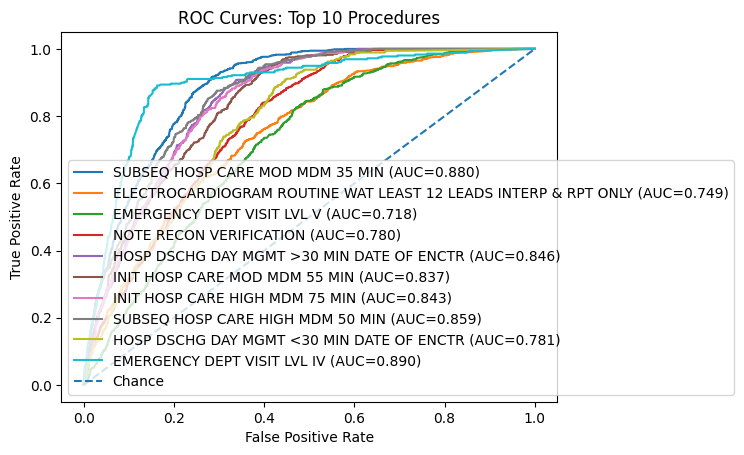

In [18]:
roc_data = {} 
best_thresholds = {}

for procedure in top10_procedures:
    cls, prob_procedure, cls_metrics, best_thresh = fit_and_eval_cls(
        base_features, procedure, 
        f"Procedure {procedure}", df_train, df_test,
    )

    results_df[f"prob_{procedure}"] = prob_procedure
    best_thresholds[procedure] = best_thresh

    y_true = np.asarray(df_test[procedure].to_numpy()).astype(int)
    fpr, tpr, _ = roc_curve(y_true, prob_procedure)


    fpr, tpr, _ = roc_curve(y_true, prob_procedure)
    roc_auc = auc(fpr, tpr)
    roc_data[procedure] = (fpr, tpr, roc_auc)

plt.figure()
for procedure, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{procedure} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Top 10 Procedures")
plt.legend()
plt.show()


In [19]:
# proc_desc = (df.proc_codes_seq_str.astype(str)
#       .str.split("|")
#       .explode()
#       .str.strip()
#       .loc[lambda x: x.ne("") & x.ne("nan")]
#       .value_counts())
# proc_desc.head(10)

proc_desc = (df.proc_descs_seq_str.fillna('')
      .astype(str)
      .str.split('|')
     .apply(lambda lst: {s.strip() for s in lst if s and s.strip().lower() != 'nan'})
      .explode()
      .loc[lambda x: x.ne('')]
      .value_counts())
proc_desc.head(10).index.tolist()

['SUBSEQ HOSP CARE MOD MDM 35 MIN',
 'ELECTROCARDIOGRAM ROUTINE WAT LEAST 12 LEADS INTERP & RPT ONLY',
 'EMERGENCY DEPT VISIT LVL V',
 'NOTE RECON VERIFICATION',
 'HOSP DSCHG DAY MGMT >30 MIN DATE OF ENCTR',
 'INIT HOSP CARE MOD MDM 55 MIN',
 'INIT HOSP CARE HIGH MDM 75 MIN',
 'SUBSEQ HOSP CARE HIGH MDM 50 MIN',
 'HOSP DSCHG DAY MGMT <30 MIN DATE OF ENCTR',
 'EMERGENCY DEPT VISIT LVL IV']

C:\Users\david\AppData\Local\Temp\ipykernel_21712\3890151960.py:5: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if pd.api.types.is_sparse(y_true.dtype):


0.7
0.7
0.7
0.7
0.7
0.7
0.7
0.7
0.7
0.7


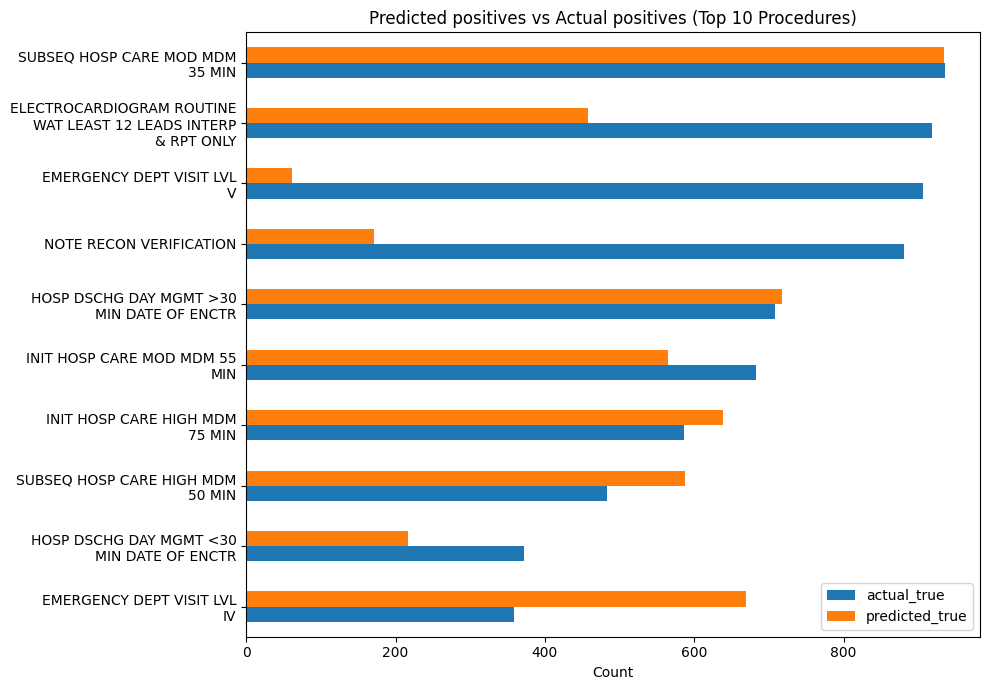

In [23]:
summary = []

for procedure in top10_procedures:
    y_true = df_test[procedure]
    if pd.api.types.is_sparse(y_true.dtype):
        y_true = y_true.sparse.to_dense()
    y_true = y_true.to_numpy().astype(int)

    y_prob = results_df[f"prob_{procedure}"].to_numpy()
    threshold = best_thresholds[procedure]
    y_pred = (y_prob >= threshold).astype(int)
    print(threshold)

    summary.append({
        "procedure": procedure,
        "actual_true": int(y_true.sum()),
        "predicted_true": int(y_pred.sum()),
    })

summary_df = pd.DataFrame(summary).set_index("procedure")
# summary_df.plot(kind="bar")

plot_df = summary_df.copy()
plot_df.index = [textwrap.fill(str(x), width=25) for x in plot_df.index]  # adjust width

ax = plot_df.sort_values("actual_true").plot(kind="barh", figsize=(10, 7))
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.set_title("Predicted positives vs Actual positives (Top 10 Procedures)")
plt.tight_layout()
plt.show()


# Predicting which day a procedure occurs

In [24]:
long_df = to_long_with_offsets(df)
dfs = []
procedures = ['SUBSEQ HOSP CARE MOD MDM 35 MIN',
 'HOSP DSCHG DAY MGMT >30 MIN DATE OF ENCTR',
 'INIT HOSP CARE MOD MDM 55 MIN',
 'INIT HOSP CARE HIGH MDM 75 MIN',
 'SUBSEQ HOSP CARE HIGH MDM 50 MIN',]
top10 = (df['proc_descs_seq_str'].fillna('').astype(str)
      .str.split('|')
     .apply(lambda lst: {s.strip() for s in lst if s and s.strip().lower() != 'nan'})
      .explode()
      .loc[lambda x: x.ne('')]
      .value_counts()
      .head(10)).index.tolist()
for index, proc in enumerate(top10):
    if proc in procedures:
        dfs.append(build_day_level_df(df, long_df, proc, max_day=7, id_col="encounter_id"))

procedure_day_df = pd.concat(dfs, ignore_index=True)

features = base_features + [
    "day",          
    "procedure"       
]

procedure_day_df["day"] = pd.to_numeric(procedure_day_df["day"], errors="coerce")
groups = procedure_day_df['patient_id'].astype(str)
gkf = GroupKFold(n_splits=5)
train_idx, test_idx = next(gkf.split(procedure_day_df, groups=groups))

procedure_day_df_train = procedure_day_df.iloc[train_idx].reset_index(drop=True)
procedure_day_df_test = procedure_day_df.iloc[test_idx].reset_index(drop=True)

pipe, proba, metrics, best_thresh = fit_and_eval_cls(
    feature_list=features,
    y_col="occurs",
    label="Day-level procedure model",
    df_train=procedure_day_df_train,
    df_test=procedure_day_df_test
)

[LightGBM] [Info] Number of positive: 22283, number of negative: 400937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023635 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 453
[LightGBM] [Info] Number of data points in the train set: 423220, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\david\OneDrive\Desktop\GraiMatter\progress\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold for occurs: 0.700
[Day-level procedure model] Classifier occurs: AUC=0.902, PR-AUC=0.311
              precision    recall  f1-score   support

         0.0      0.983     0.888     0.933    100378
         1.0      0.256     0.709     0.376      5462

    accuracy                          0.878    105840
   macro avg      0.619     0.799     0.654    105840
weighted avg      0.945     0.878     0.904    105840



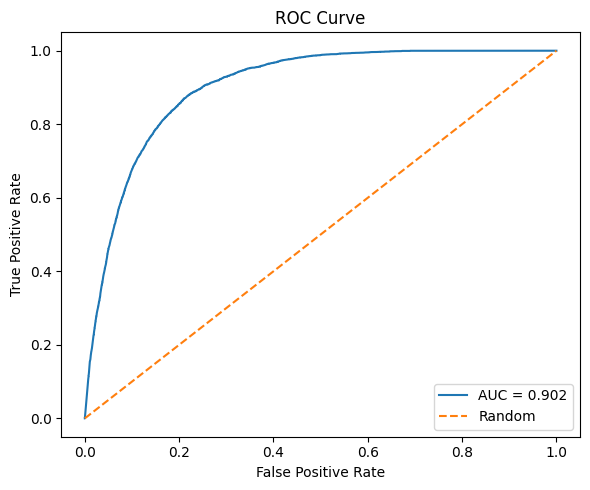

In [25]:
y_true = procedure_day_df_test["occurs"].to_numpy().astype(int)
y_score = proba

fpr, tpr, _ = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


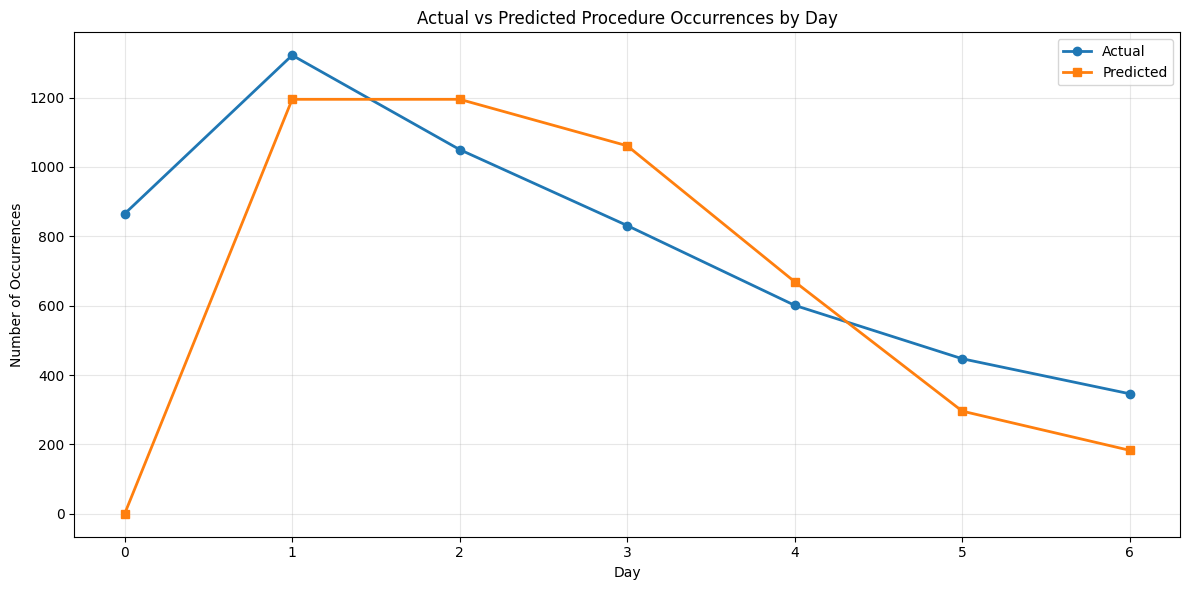

In [35]:
day_summary = procedure_day_df_test.copy()
day_summary['predicted'] = (proba >= .85).astype(int)

daily_stats = day_summary.groupby('day').agg({
    'occurs': 'sum',
    'predicted': 'sum'
}).reset_index()
daily_stats.columns = ['day', 'actual', 'predicted']

plt.figure(figsize=(12, 6))
plt.plot(daily_stats['day'], daily_stats['actual'], marker='o', label='Actual', linewidth=2)
plt.plot(daily_stats['day'], daily_stats['predicted'], marker='s', label='Predicted', linewidth=2)
plt.xlabel('Day')
plt.ylabel('Number of Occurrences')
plt.title('Actual vs Predicted Procedure Occurrences by Day')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_22268\2146056316.py:5: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if pd.api.types.is_sparse(actual_df[c].dtype):


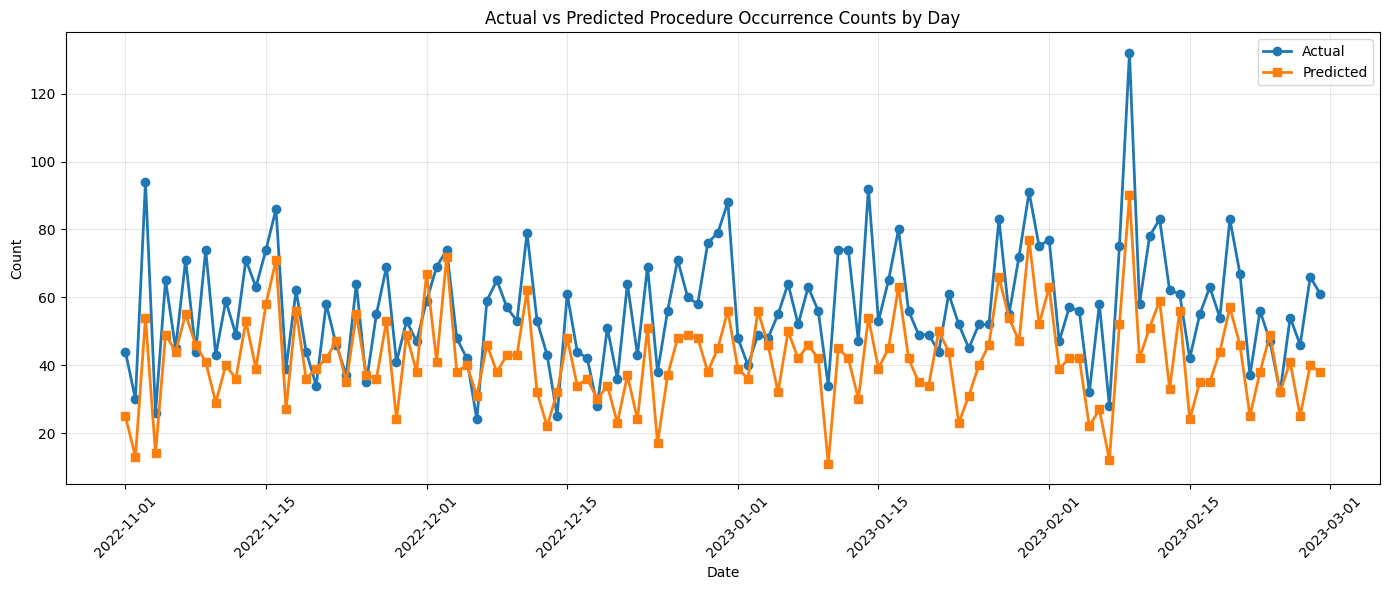

In [25]:
enc = df_test[['encounter_id','encounter_start_dt']].copy()
enc['encounter_start_dt'] = pd.to_datetime(enc['encounter_start_dt'], errors='coerce')
actual_df = df_test[top10_procedures].copy()
for c in actual_df.columns:
    if pd.api.types.is_sparse(actual_df[c].dtype):
        actual_df[c] = actual_df[c].sparse.to_dense()
actual_counts_per_enc = actual_df.fillna(0).astype(int).sum(axis=1)
predicted_df = pd.DataFrame({
    proc: (results_df[f"prob_{proc}"].to_numpy() >= best_thresholds[proc]).astype(int)
    for proc in top10_procedures
}, index=df_test.index)
predicted_counts_per_enc = predicted_df.sum(axis=1)
day_df = pd.DataFrame({
    'encounter_start_dt': enc['encounter_start_dt'],
    'actual_count': actual_counts_per_enc,
    'predicted_count': predicted_counts_per_enc
})
day_df['day'] = day_df['encounter_start_dt'].dt.floor('D')
daily_stats = day_df.groupby('day').agg({'actual_count':'sum','predicted_count':'sum'}).reset_index().sort_values('day')
plt.figure(figsize=(14,6))
plt.plot(daily_stats['day'], daily_stats['actual_count'], marker='o', label='Actual', linewidth=2)
plt.plot(daily_stats['day'], daily_stats['predicted_count'], marker='s', label='Predicted', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Actual vs Predicted Procedure Occurrence Counts by Day')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

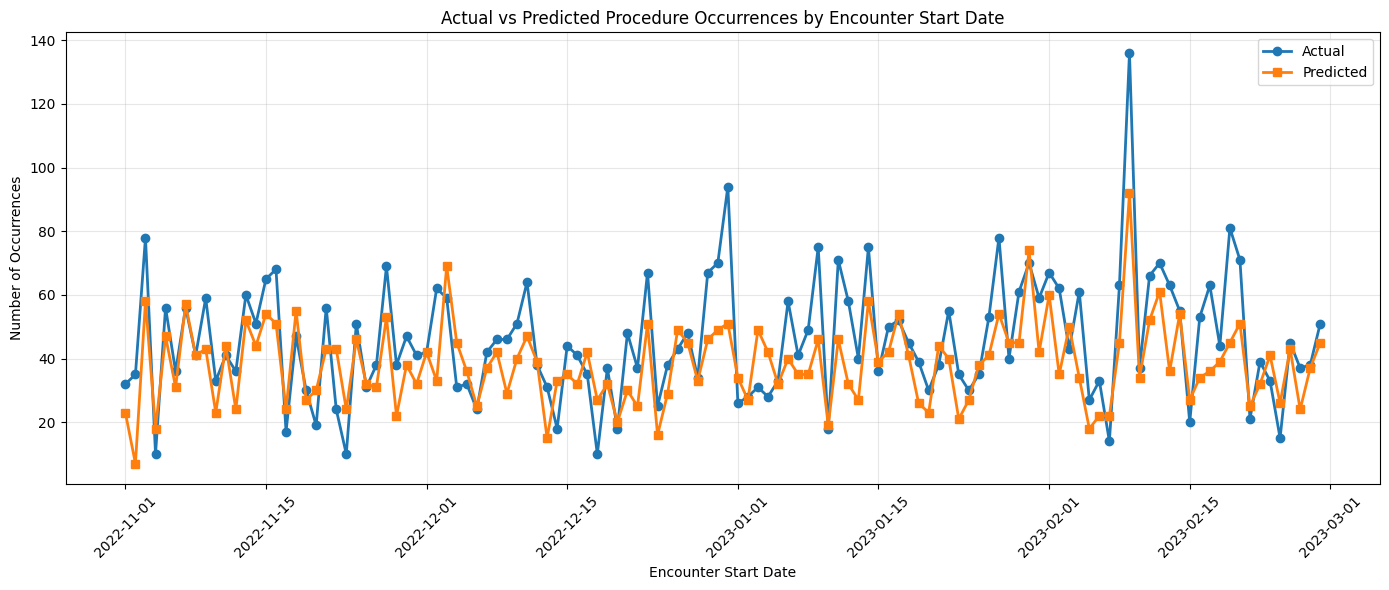

In [37]:
day_summary = procedure_day_df_test.copy()
day_summary['predicted'] = (proba >= .85).astype(int)

daily_stats = day_summary.groupby('encounter_start_dt').agg({
    'occurs': 'sum',
    'predicted': 'sum'
}).reset_index()
daily_stats.columns = ['encounter_start_dt', 'actual', 'predicted']
daily_stats = daily_stats.sort_values('encounter_start_dt')

plt.figure(figsize=(14, 6))
plt.plot(daily_stats['encounter_start_dt'], daily_stats['actual'], marker='o', label='Actual', linewidth=2)
plt.plot(daily_stats['encounter_start_dt'], daily_stats['predicted'], marker='s', label='Predicted', linewidth=2)
plt.xlabel('Encounter Start Date')
plt.ylabel('Number of Occurrences')
plt.title('Actual vs Predicted Procedure Occurrences by Encounter Start Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

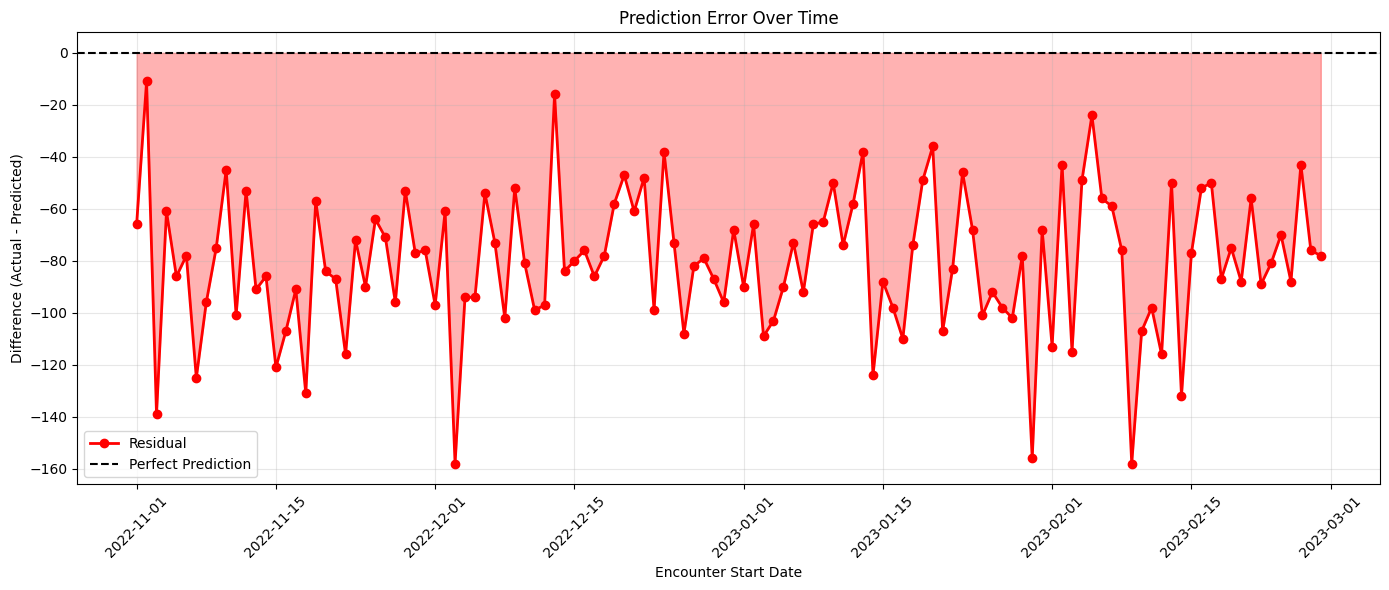

Mean Error: -80.75
Std Dev: 27.26
Min Error: -158.00
Max Error: -11.00


In [28]:

day_summary = procedure_day_df_test.copy()
day_summary['predicted'] = (proba >= best_thresh).astype(int)
day_summary['encounter_start_dt'] = pd.to_datetime(day_summary['encounter_start_dt'], errors='coerce')

daily_stats = (
    day_summary.groupby('encounter_start_dt')
    .agg({'occurs': 'sum', 'predicted': 'sum'})
    .reset_index()
    .rename(columns={'occurs': 'actual'})
    .sort_values('encounter_start_dt')
)

# Calculate residuals (error)
daily_stats['residual'] = daily_stats['actual'] - daily_stats['predicted']

# Plot residuals over time
plt.figure(figsize=(14, 6))
plt.plot(daily_stats['encounter_start_dt'], daily_stats['residual'], marker='o', linewidth=2, color='red', label='Residual')
plt.axhline(y=0, color='black', linestyle='--', label='Perfect Prediction')
plt.fill_between(daily_stats['encounter_start_dt'], 0, daily_stats['residual'], alpha=0.3, color='red')
plt.xlabel('Encounter Start Date')
plt.ylabel('Difference (Actual - Predicted)')
plt.title('Prediction Error Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print summary stats
print(f"Mean Error: {daily_stats['residual'].mean():.2f}")
print(f"Std Dev: {daily_stats['residual'].std():.2f}")
print(f"Min Error: {daily_stats['residual'].min():.2f}")
print(f"Max Error: {daily_stats['residual'].max():.2f}")

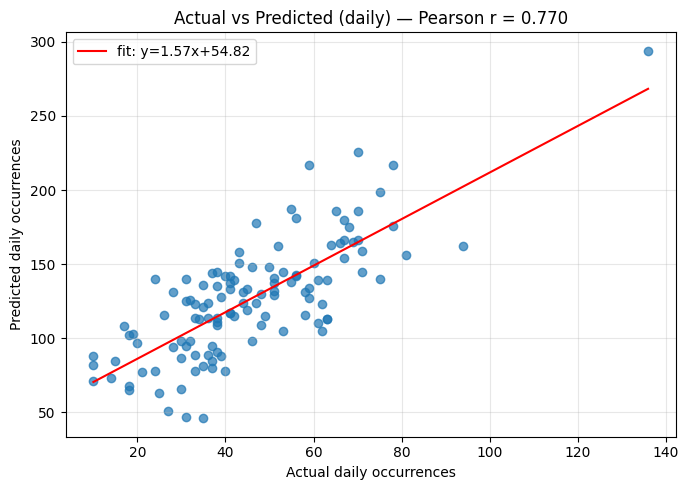

In [40]:
day_summary = procedure_day_df_test.copy()
day_summary['predicted'] = (proba >= best_thresh).astype(int)
day_summary['encounter_start_dt'] = pd.to_datetime(day_summary['encounter_start_dt'], errors='coerce')

daily_stats = (
    day_summary.groupby('encounter_start_dt')
    .agg({'occurs': 'sum', 'predicted': 'sum'})
    .reset_index()
    .rename(columns={'occurs': 'actual', 'predicted': 'predicted'})
    .sort_values('encounter_start_dt')
)

r = np.nan
if len(daily_stats) >= 2:
    r = np.corrcoef(daily_stats['actual'], daily_stats['predicted'])[0, 1]

plt.figure(figsize=(7, 5))
plt.scatter(daily_stats['actual'], daily_stats['predicted'], alpha=0.7)
if daily_stats['actual'].nunique() > 1:
    m, b = np.polyfit(daily_stats['actual'], daily_stats['predicted'], 1)
    xs = np.linspace(daily_stats['actual'].min(), daily_stats['actual'].max(), 100)
    plt.plot(xs, m * xs + b, color='red', label=f'fit: y={m:.2f}x+{b:.2f}')
plt.xlabel('Actual daily occurrences')
plt.ylabel('Predicted daily occurrences')
plt.title(f'Actual vs Predicted (daily) — Pearson r = {r:.3f}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
procedure_day_df_test.predicted

AttributeError: 'DataFrame' object has no attribute 'predicted'

# map patient id to list of procedures

In [16]:
patient_proc_map = {}
for pid, seq in zip(df['patient_id'], df['proc_descs_seq_str']):
    if pd.isna(seq):
        patient_proc_map[pid] = set()
    else:
        descs = [s.strip() for s in str(seq).split('|') if s.strip()]
        patient_proc_map[pid] = descs

In [17]:
patient_proc_map

{'0000fa8c4cfecf9f7e26e462a990af1ad85a1bfab7f43ec9bdd780ba110cbcad': ['ZZ INIT OBSV CARE LVL III',
  'ZZ SUBSEQ OBSV CARE LVL 2',
  'ZZ OBSERVA CARE DSCHG DAY MGT'],
 '00010b29ec5fd2ad40834318f6b429961059a614fbfece07587989bb28c43451': ['ZZ INIT OBSV CARE LVL II',
  'EMERGENCY DEPT VISIT LVL V',
  'ANESTH UPPER GASTROINTSTNL ENDO PROC, SCOPE  PROXIMAL TO DUODENUM; NOS',
  'NOTE RECON VERIFICATION',
  'UPPER GI ENDOSCOPY WREMVL FB',
  'ZZ SUBSEQ OBSV CARE LVL 3',
  'OFFICE OP VISIT NEW PT LEVEL III',
  'NOTE RECON VERIFICATION',
  'ZZ OBSERVA CARE DSCHG DAY MGT',
  'OFFICE OP VISIT EST PT LEVEL II'],
 '00069f08d03e7656de01529806a59e6f7802f7d2380b3b3d05755afcbe85081c': ['INIT HOSP CARE MOD MDM 55 MIN',
  'SUBSEQ HOSP CARE MOD MDM 35 MIN',
  'SUBSEQ HOSP CARE LOW MDM 25 MIN',
  'HOSP DSCHG DAY MGMT >30 MIN DATE OF ENCTR'],
 '0011226504d8e566cd00f2fd24dab680409b58aa39fa9b523f46d541c7f2c673': ['ELECTROCARDIOGRAM ROUTINE WAT LEAST 12 LEADS INTERP & RPT ONLY',
  'EMERGENCY DEPT VISIT LVL V',
 